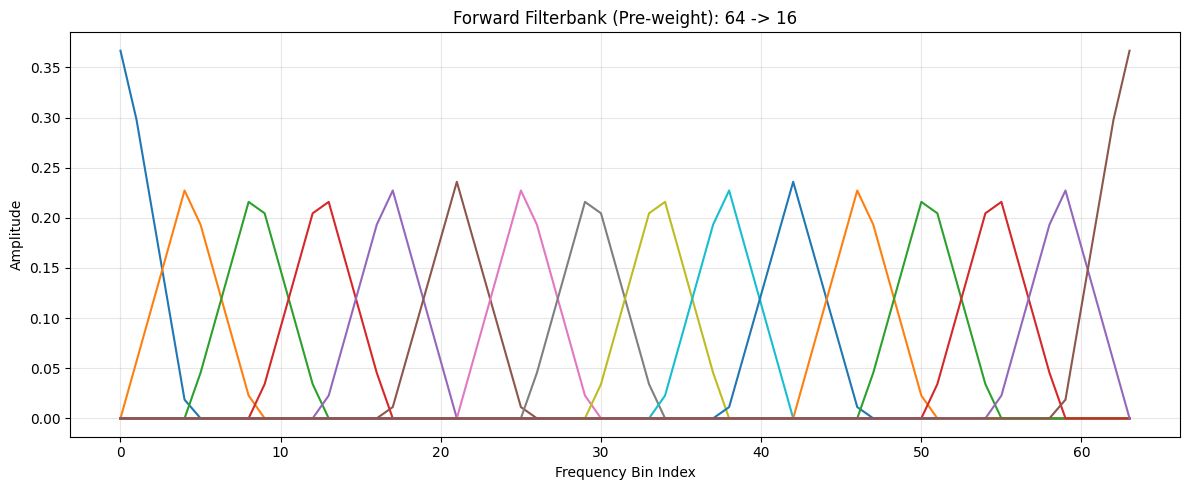

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import typing as tp

# --- Original Function ---
def rf_pre_post_lin(
    freq: int,
    n_filter: int,
    init: tp.Optional[str],
    bias: bool,
    sr: int = 16_000
) -> tp.Tuple[nn.Module, nn.Module]:
    assert init in [None, "linear", "linear_fixed"]
    pre = nn.Linear(freq, n_filter, bias=bias)
    post = nn.Linear(n_filter, freq, bias=bias)

    if init is None:
        return pre, post

    f_filter = torch.linspace(0, sr // 2, n_filter)
    delta_f = sr // 2 / n_filter
    f_freqs = torch.linspace(0, sr // 2, freq)
    
    down = f_filter[1:, None] - f_freqs[None, :]
    down = down / delta_f
    down = F.pad(down, (0, 0, 0, 1), value=1.0)
    
    up = f_freqs[None, :] - f_filter[:-1, None]
    up = up / delta_f
    up = F.pad(up, (0, 0, 1, 0), value=1.0)
    
    pre_weight = torch.max(up.new_zeros(1), torch.min(down, up))
    post_weight = pre_weight.transpose(0, 1)
    
    # Normalization for visualization purposes
    pre_weight = pre_weight / pre_weight.sum(dim=1, keepdim=True)
    post_weight = post_weight / post_weight.sum(dim=1, keepdim=True)

    if init.endswith("_fixed"):
        delattr(pre, "weight")
        delattr(post, "weight")
        pre.register_buffer("weight", pre_weight.contiguous().clone())
        post.register_buffer("weight", post_weight.contiguous().clone())
    else:
        pre.weight.data.copy_(pre_weight)
        post.weight.data.copy_(post_weight)

    return pre, post

# --- Visualization Code ---
def visualize_filterbank(freq=32, n_filter=16, sr=16000):
    # 1. Generate layers
    pre, post = rf_pre_post_lin(freq, n_filter, init="linear_fixed", bias=False, sr=sr)
    
    # 2. Extract weights
    # weight shape: [out_features, in_features]
    pre_w = pre.weight.detach().cpu().numpy()   # [n_filter, freq]
    post_w = post.weight.detach().cpu().numpy() # [freq, n_filter]

    # 3. Plotting
    fig, axes = plt.subplots(1, 1, figsize=(12, 5))
    
    # Plot 1: Pre-weight (Forward Filterbank)
    # Each row is a triangular filter
    for i in range(0, n_filter, max(1, n_filter // 10)): # Show subset of filters for clarity
        axes.plot(pre_w[i], label=f'Filter {i}')
    axes.set_title(f"Forward Filterbank (Pre-weight): {freq} -> {n_filter}")
    axes.set_xlabel("Frequency Bin Index")
    axes.set_ylabel("Amplitude")
    axes.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# freq: typical STFT bin count (e.g., n_fft//2 + 1)
visualize_filterbank(freq=64, n_filter=16, sr=16000)